# Rolling Window Model on Home Credit Data
This notebook performs a rolling window model training and evaluation using the `SIMULATED_MONTH` feature from the processed Home Credit dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
# Load dataset
df = pd.read_csv('hc_processed.csv')
df = df.sort_values('SIMULATED_MONTH')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_PREV_AMT_APPLICATION,EARLIEST_DAYS_DECISION,NUM_PREV_APPLICATIONS,SIMULATED_MONTH
3050,103560,0,Cash loans,F,N,N,2,225000.0,1506816.0,45814.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26599,130919,0,Cash loans,F,N,N,0,112500.0,518562.0,20421.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20163,123520,0,Cash loans,F,N,N,0,270000.0,1183963.5,31360.5,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
10109,111767,0,Cash loans,F,N,N,0,157500.0,247500.0,6804.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10107,111765,0,Cash loans,F,N,Y,0,76536.0,450000.0,12505.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Define features and target
features = [
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH',
    'AVG_PREV_AMT_APPLICATION', 'NUM_PREV_APPLICATIONS',
    'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED'  # Changed NumberOfDependents to CNT_FAM_MEMBERS
]
target = 'TARGET'

In [11]:
# Rolling Window Parameters
window_size = 3   # train on 3 months
step_size = 1     # slide by 1 month

# Convert to int to avoid TypeError
min_month = int(df['SIMULATED_MONTH'].min())
max_month = int(df['SIMULATED_MONTH'].max())

results = []


In [12]:
# Rolling Window Loop
for start_month in range(min_month, max_month - window_size):
    train_months = list(range(start_month, start_month + window_size))
    test_month = start_month + window_size

    train_data = df[df['SIMULATED_MONTH'].isin(train_months)]
    test_data = df[df['SIMULATED_MONTH'] == test_month]

    if test_data.empty or train_data.empty:
        continue

    X_train = train_data[features]
    y_train = train_data[target]
    X_test = test_data[features]
    y_test = test_data[target]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Train Months': train_months,
        'Test Month': test_month,
        'Accuracy': acc
    })

In [13]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.head()

,Train Months,Test Month,Accuracy
0,"[0, 1, 2]",3,0.920000
1,"[1, 2, 3]",4,0.909091
2,"[2, 3, 4]",5,0.901235
3,"[3, 4, 5]",6,0.904494
4,"[4, 5, 6]",7,0.917582


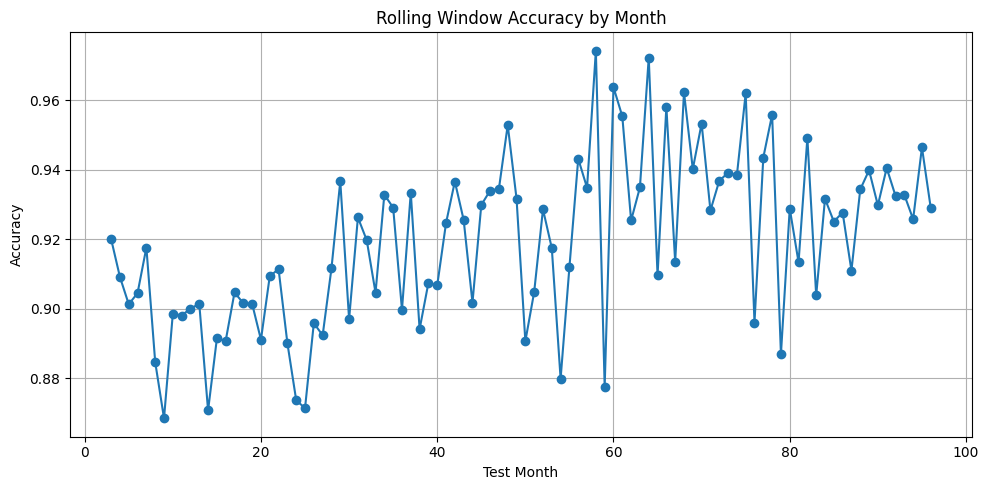

In [14]:
# Plot Accuracy over Test Months
plt.figure(figsize=(10, 5))
plt.plot(results_df['Test Month'], results_df['Accuracy'], marker='o')
plt.title('Rolling Window Accuracy by Month')
plt.xlabel('Test Month')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()